# Figure 5: Empirical counterfactual outcome paths

This notebook reproduces **Figure 5** in the paper.

It runs the empirical analysis for the three datasets used in the paper:

- Reunification of Germany
- Terrorist conflict in the Basque Country
- Tobacco control program in California

For each dataset, the notebook fits the methods shown in the paper and plots the observed treated outcome together with the synthetic counterfactual paths.

## How to run

Run all cells from top to bottom.

## Notes

- The notebook reads the empirical datasets from `dataset/`.
- The final plots correspond to the three panels of Figure 5.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mmscm import *

In [12]:
DATA_DIR = "dataset/"

In [13]:
#Import data
data = pd.read_csv(DATA_DIR + "german_reunification.csv")
data = data.drop(columns="code", axis=1)

In [14]:
target_unit_var = "country"
target_unit = "West Germany"
target_year_var = "year"
target_year = 1990

target_outcome_var = "gdp"

In [15]:
abadiescm2 = MMSCM(data, "MMSCM", target_unit_var, target_unit, target_outcome_var, target_year_var, target_year, poly=2)
abadiescm2.train_param()
orignal_val, abadiescm_pred2 = abadiescm2.predict(bias=True)

abadiescm10 = MMSCM(data, "MMSCM", target_unit_var, target_unit, target_outcome_var, target_year_var, target_year, poly=10)
abadiescm10.train_param()
orignal_val, abadiescm_pred10 = abadiescm10.predict(bias=True)

abadiescm100 = MMSCM(data, "MMSCM", target_unit_var, target_unit, target_outcome_var, target_year_var, target_year, poly=100)
abadiescm100.train_param()
orignal_val, abadiescm_pred100 = abadiescm100.predict(bias=True)

abadiescm = MMSCM(data, "Abadie", target_unit_var, target_unit, target_outcome_var, target_year_var, target_year)
abadiescm.train_param()
orignal_val, abadiescm_pred = abadiescm.predict(bias=True)

discoscm = MMSCM(data, "DiSCo", target_unit_var, target_unit, target_outcome_var, target_year_var, target_year)
discoscm.train_param()
orignal_val, discoscm_pred = discoscm.predict(bias=True)


In [16]:
sub_data = data.copy()

unit_names = sub_data[target_unit_var].unique()

for u in unit_names:
    temp_data = sub_data[(sub_data[target_unit_var] == u) & (sub_data[target_year_var] <= target_year)]
    target_outcome_varues = temp_data[target_outcome_var]
    mean_val = np.mean(target_outcome_varues)
    if u == target_unit:
        target_mean_val = mean_val
    sub_data.loc[sub_data[target_unit_var] == u, target_outcome_var] = sub_data.loc[sub_data[target_unit_var] == u, target_outcome_var]  - mean_val
    
fpscm = MMSCM(sub_data, "Abadie", target_unit_var, target_unit, target_outcome_var, target_year_var, target_year)
fpscm.train_param()
_, fpscm_pred = fpscm.predict(bias=False)
fpscm_pred = fpscm_pred + target_mean_val


sub_data = data.copy()

unit_names = sub_data[target_unit_var].unique()

for u in unit_names:
    temp_data = sub_data[(sub_data[target_unit_var] == u) & (sub_data[target_year_var] <= target_year)]
    target_outcome_varues = temp_data[target_outcome_var]
    mean_val = np.mean(target_outcome_varues)
    if u == target_unit:
        target_mean_val = mean_val
    sub_data.loc[sub_data[target_unit_var] == u, target_outcome_var] = sub_data.loc[sub_data[target_unit_var] == u, target_outcome_var]  - mean_val
    
fpscm2 = MMSCM(sub_data, "MMSCM", target_unit_var, target_unit, target_outcome_var, target_year_var, target_year, poly=2)
fpscm2.train_param()
_, fpscm_pred2 = fpscm2.predict(bias=False)
fpscm_pred2 = fpscm_pred2 + target_mean_val

/var/folders/11/m8mvh3fs3jn1tk4r49vpy8rh0000gn/T/ipykernel_59059/115931300.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-6967.77419355 -6917.77419355 -6743.77419355 -6619.77419355
 -6426.77419355 -6179.77419355 -5872.77419355 -5692.77419355
 -5352.77419355 -5041.77419355 -4847.77419355 -4484.77419355
 -4008.77419355 -3382.77419355 -2895.77419355 -2327.77419355
 -1546.77419355  -700.77419355   382.22580645  1459.22580645
  2339.22580645  3686.22580645  4093.22580645  5161.22580645
  6702.22580645  7753.22580645  8592.22580645  9560.22580645
 10864.22580645 12200.22580645 13217.22580645 13660.22580645
 14662.22580645 15562.22580645 16823.22580645 17727.22580645
 18967.22580645 20415.22580645 21672.22580645 23181.22580645
 24756.22580645 25494.22580645 26333.22580645 27701.22580645]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  sub_data.loc[sub_data[targe

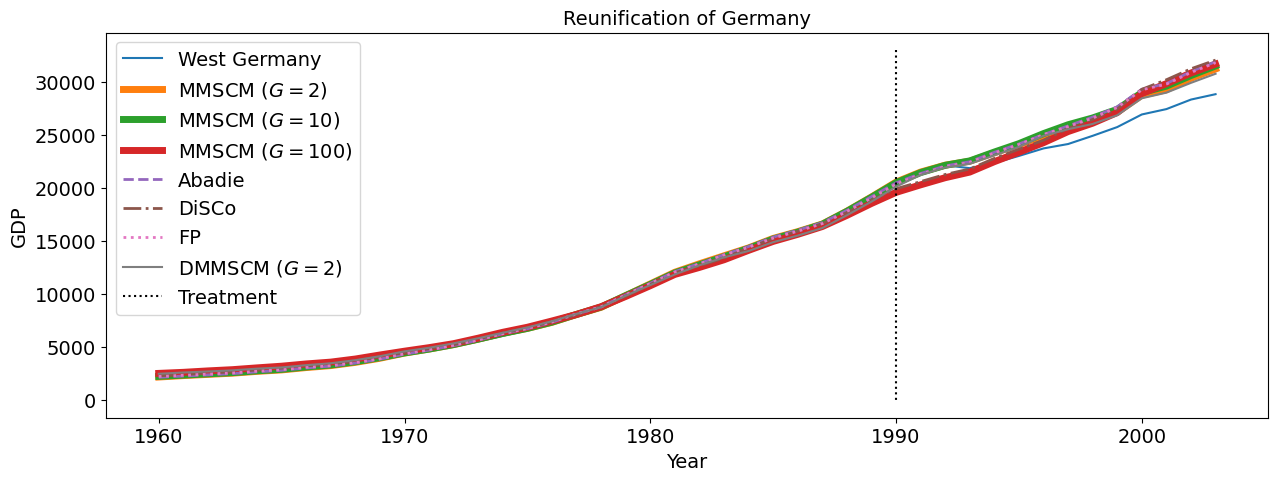

In [17]:

year = np.array(data["year"].unique(), np.int64)

plt.figure(figsize=(15, 5))
plt.plot(year, orignal_val, label="West Germany")
plt.plot(year, abadiescm_pred2, label="MMSCM ($G = 2$)", linewidth=5,)
#plt.plot(year, abadiescm_pred3, label="Abadie2")
plt.plot(year, abadiescm_pred10, label="MMSCM ($G = 10$)", linewidth=5)
#plt.plot(year, abadiescm_pred20, label="Abadie2")
plt.plot(year, abadiescm_pred100, label="MMSCM ($G = 100$)", linewidth=5)
plt.plot(year, abadiescm_pred, label="Abadie", linewidth=2, linestyle='--')
plt.plot(year, discoscm_pred, label="DiSCo", linewidth=2, linestyle='-.')
plt.plot(year, fpscm_pred, label="FP", linewidth=2, linestyle=':')
plt.plot(year, fpscm_pred2, label="DMMSCM ($G = 2$)")



#plt.plot(ddscm_pred, label="DRSCM (w/o bias term)")
#plt.plot(ddscm_pred_nobias, label="DDSCM (w/o bias term)")
# 軸ラベルの設定
plt.title("Reunification of Germany", size = 14)

plt.xlabel("Year", size = 14, weight = "light")
plt.ylabel("GDP", size = 14, weight = "light")

plt.xticks(size = 14)
plt.yticks(size = 14)

plt.vlines(target_year, 33000, 0, color='black', linestyles='dotted', label="Treatment")
plt.legend(fontsize = 14)
plt.show()

In [18]:
#Import data
data = pd.read_csv(DATA_DIR + "basque_data" + ".csv")
data = data.drop(columns=["regionno", "Unnamed: 0"], axis=1) #Drop superfluous columns
data = data.loc[data["regionname"] != "Spain (Espana)"] #Exclude spain as a valid control unit, as it includes basque, the treated unit.

In [19]:
target_unit_var = "regionname"
target_unit = "Basque Country (Pais Vasco)"
target_year_var = "year"
target_year = 1970

target_outcome_var = "gdpcap"

In [20]:
abadiescm2 = MMSCM(data, "MMSCM", target_unit_var, target_unit, target_outcome_var, target_year_var, target_year, poly=2)
abadiescm2.train_param()
orignal_val, abadiescm_pred2 = abadiescm2.predict(bias=True)

abadiescm10 = MMSCM(data, "MMSCM", target_unit_var, target_unit, target_outcome_var, target_year_var, target_year, poly=10)
abadiescm10.train_param()
orignal_val, abadiescm_pred10 = abadiescm10.predict(bias=True)

abadiescm100 = MMSCM(data, "MMSCM", target_unit_var, target_unit, target_outcome_var, target_year_var, target_year, poly=100)
abadiescm100.train_param()
orignal_val, abadiescm_pred100 = abadiescm100.predict(bias=True)

abadiescm = MMSCM(data, "Abadie", target_unit_var, target_unit, target_outcome_var, target_year_var, target_year)
abadiescm.train_param()
orignal_val, abadiescm_pred = abadiescm.predict(bias=True)

discoscm = MMSCM(data, "DiSCo", target_unit_var, target_unit, target_outcome_var, target_year_var, target_year)
discoscm.train_param()
orignal_val, discoscm_pred = discoscm.predict(bias=True)


In [21]:
sub_data = data.copy()

unit_names = sub_data[target_unit_var].unique()

for u in unit_names:
    temp_data = sub_data[(sub_data[target_unit_var] == u) & (sub_data[target_year_var] <= target_year)]
    target_outcome_varues = temp_data[target_outcome_var]
    mean_val = np.mean(target_outcome_varues)
    if u == target_unit:
        target_mean_val = mean_val
    sub_data.loc[sub_data[target_unit_var] == u, target_outcome_var] = sub_data.loc[sub_data[target_unit_var] == u, target_outcome_var]  - mean_val
    
fpscm = MMSCM(sub_data, "Abadie", target_unit_var, target_unit, target_outcome_var, target_year_var, target_year)
fpscm.train_param()
_, fpscm_pred = fpscm.predict(bias=False)
fpscm_pred = fpscm_pred + target_mean_val


sub_data = data.copy()

unit_names = sub_data[target_unit_var].unique()

for u in unit_names:
    temp_data = sub_data[(sub_data[target_unit_var] == u) & (sub_data[target_year_var] <= target_year)]
    target_outcome_varues = temp_data[target_outcome_var]
    mean_val = np.mean(target_outcome_varues)
    if u == target_unit:
        target_mean_val = mean_val
    sub_data.loc[sub_data[target_unit_var] == u, target_outcome_var] = sub_data.loc[sub_data[target_unit_var] == u, target_outcome_var]  - mean_val
    
fpscm2 = MMSCM(sub_data, "MMSCM", target_unit_var, target_unit, target_outcome_var, target_year_var, target_year, poly=2)
fpscm2.train_param()
_, fpscm_pred2 = fpscm2.predict(bias=False)
fpscm_pred2 = fpscm_pred2 + target_mean_val

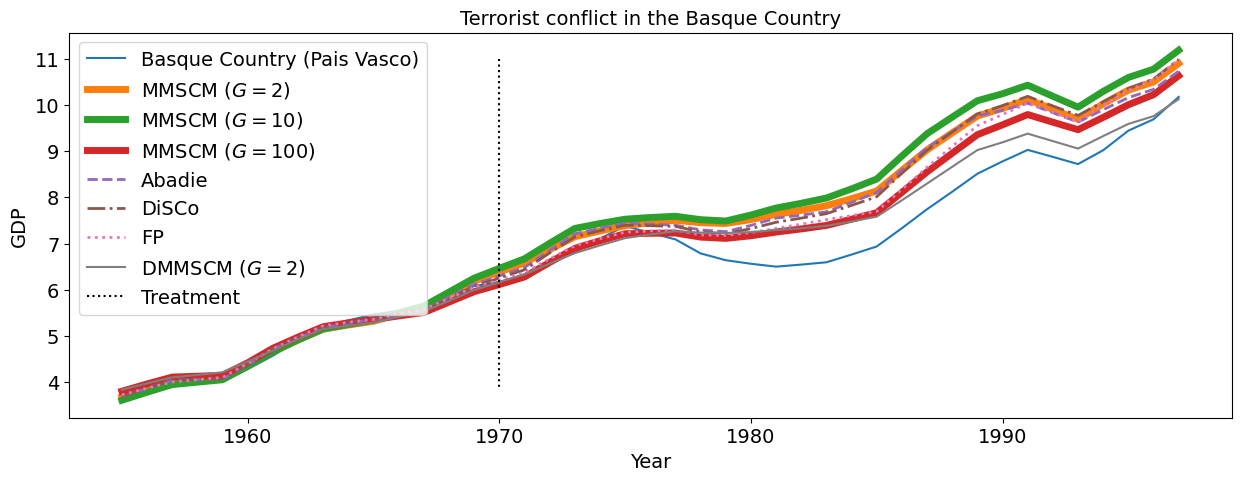

In [22]:

year = np.array(data["year"].unique(), np.int64)

plt.figure(figsize=(15, 5))
plt.plot(year, orignal_val, label="Basque Country (Pais Vasco)")
plt.plot(year, abadiescm_pred2, label="MMSCM ($G = 2$)", linewidth=5,)
#plt.plot(year, abadiescm_pred3, label="Abadie2")
plt.plot(year, abadiescm_pred10, label="MMSCM ($G = 10$)", linewidth=5)
#plt.plot(year, abadiescm_pred20, label="Abadie2")
plt.plot(year, abadiescm_pred100, label="MMSCM ($G = 100$)", linewidth=5)
plt.plot(year, abadiescm_pred, label="Abadie", linewidth=2, linestyle='--')
plt.plot(year, discoscm_pred, label="DiSCo", linewidth=2, linestyle='-.')
plt.plot(year, fpscm_pred, label="FP", linewidth=2, linestyle=':')
plt.plot(year, fpscm_pred2, label="DMMSCM ($G = 2$)")


#plt.plot(ddscm_pred, label="DRSCM (w/o bias term)")
#plt.plot(ddscm_pred_nobias, label="DDSCM (w/o bias term)")
# 軸ラベルの設定
plt.title("Terrorist conflict in the Basque Country", size = 14)
plt.xlabel("Year", size = 14, weight = "light")
plt.ylabel("GDP", size = 14, weight = "light")

plt.xticks(size = 14)
plt.yticks(size = 14)

plt.vlines(target_year, 11, 3.85, color='black', linestyles='dotted', label="Treatment")
plt.legend(fontsize = 14)
plt.show()

In [23]:
#Import data
data = pd.read_csv(DATA_DIR + "smoking_data" + ".csv")

In [24]:
target_unit_var = "state"
target_unit = "California"
target_year_var = "year"
target_year = 1989

target_outcome_var = "cigsale"

In [25]:
abadiescm2 = MMSCM(data, "MMSCM", target_unit_var, target_unit, target_outcome_var, target_year_var, target_year, poly=2)
abadiescm2.train_param()
orignal_val, abadiescm_pred2 = abadiescm2.predict(bias=True)

abadiescm10 = MMSCM(data, "MMSCM", target_unit_var, target_unit, target_outcome_var, target_year_var, target_year, poly=10)
abadiescm10.train_param()
orignal_val, abadiescm_pred10 = abadiescm10.predict(bias=True)

abadiescm100 = MMSCM(data, "MMSCM", target_unit_var, target_unit, target_outcome_var, target_year_var, target_year, poly=100)
abadiescm100.train_param()
orignal_val, abadiescm_pred100 = abadiescm100.predict(bias=True)

abadiescm = MMSCM(data, "Abadie", target_unit_var, target_unit, target_outcome_var, target_year_var, target_year)
abadiescm.train_param()
orignal_val, abadiescm_pred = abadiescm.predict(bias=True)

discoscm = MMSCM(data, "DiSCo", target_unit_var, target_unit, target_outcome_var, target_year_var, target_year)
discoscm.train_param()
orignal_val, discoscm_pred = discoscm.predict(bias=True)


In [26]:
sub_data = data.copy()

unit_names = sub_data[target_unit_var].unique()

for u in unit_names:
    temp_data = sub_data[(sub_data[target_unit_var] == u) & (sub_data[target_year_var] <= target_year)]
    target_outcome_varues = temp_data[target_outcome_var]
    mean_val = np.mean(target_outcome_varues)
    if u == target_unit:
        target_mean_val = mean_val
    sub_data.loc[sub_data[target_unit_var] == u, target_outcome_var] = sub_data.loc[sub_data[target_unit_var] == u, target_outcome_var]  - mean_val
    
fpscm = MMSCM(sub_data, "Abadie", target_unit_var, target_unit, target_outcome_var, target_year_var, target_year)
fpscm.train_param()
_, fpscm_pred = fpscm.predict(bias=False)
fpscm_pred = fpscm_pred + target_mean_val


sub_data = data.copy()

unit_names = sub_data[target_unit_var].unique()

for u in unit_names:
    temp_data = sub_data[(sub_data[target_unit_var] == u) & (sub_data[target_year_var] <= target_year)]
    target_outcome_varues = temp_data[target_outcome_var]
    mean_val = np.mean(target_outcome_varues)
    if u == target_unit:
        target_mean_val = mean_val
    sub_data.loc[sub_data[target_unit_var] == u, target_outcome_var] = sub_data.loc[sub_data[target_unit_var] == u, target_outcome_var]  - mean_val
    
fpscm2 = MMSCM(sub_data, "MMSCM", target_unit_var, target_unit, target_outcome_var, target_year_var, target_year, poly=2)
fpscm2.train_param()
_, fpscm_pred2 = fpscm2.predict(bias=False)
fpscm_pred2 = fpscm_pred2 + target_mean_val

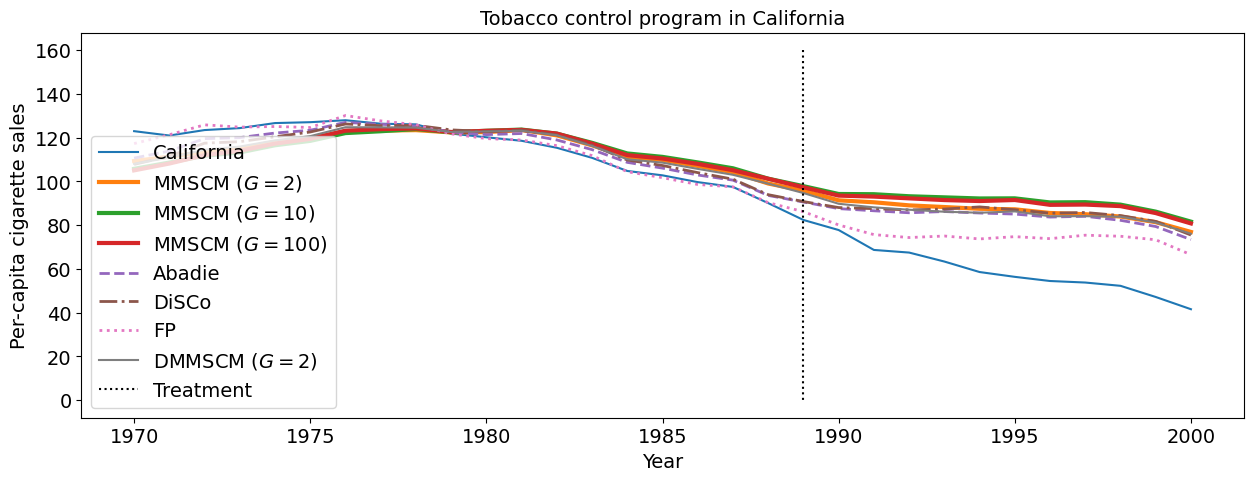

In [27]:

year = np.array(data["year"].unique(), np.int64)

plt.figure(figsize=(15, 5))
plt.plot(year, orignal_val, label="California")
plt.plot(year, abadiescm_pred2, label="MMSCM ($G = 2$)", linewidth=3,)
#plt.plot(year, abadiescm_pred3, label="Abadie2")
plt.plot(year, abadiescm_pred10, label="MMSCM ($G = 10$)", linewidth=3)
#plt.plot(year, abadiescm_pred20, label="Abadie2")
plt.plot(year, abadiescm_pred100, label="MMSCM ($G = 100$)", linewidth=3)
plt.plot(year, abadiescm_pred, label="Abadie", linewidth=2, linestyle='--')
plt.plot(year, discoscm_pred, label="DiSCo", linewidth=2, linestyle='-.')
plt.plot(year, fpscm_pred, label="FP", linewidth=2, linestyle=':')
plt.plot(year, fpscm_pred2, label="DMMSCM ($G = 2$)")


plt.title("Tobacco control program in California", size = 14)
plt.xlabel("Year", size = 14, weight = "light")
plt.ylabel("Per-capita cigarette sales", size = 14, weight = "light")

plt.xticks(size = 14)
plt.yticks(size = 14)

plt.vlines(target_year, 160, 0, color='black', linestyles='dotted', label="Treatment")
plt.legend(fontsize = 14)
plt.show()